# Spectrogram Explorer

Use this notebook to inspect individual IQ captures before training.

1. Update the configuration cell with the file path, sample rate (Hz), optional `num_samples`, and `offset`.
2. Run the plotting cell to render a spectrogram with frequency on the Y axis and time on the X axis.
3. The title lists the source file name and the sample index range that was plotted.


In [61]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy import signal

def load_waveform(file_path: Path, waveform_key: str = "waveform") -> np.ndarray:
    file_path = Path(file_path)
    suffix = file_path.suffix.lower()
    if suffix == ".mat":
        mat = loadmat(file_path)
        if waveform_key not in mat:
            raise KeyError(f"Key '{waveform_key}' not found in {file_path}")
        data = mat[waveform_key]
        if data.ndim > 1:
            data = data.squeeze()
        return np.asarray(data).astype(np.complex64)
    if suffix == ".dat":
        raw = np.fromfile(file_path, dtype=np.float32)
        usable = (raw.size // 2) * 2
        if usable == 0:
            raise ValueError(f"{file_path} does not contain interleaved IQ samples")
        iq = raw[:usable].view(np.complex64)
        return iq
    if suffix == ".bin":
        return np.fromfile(file_path, dtype=np.complex128).astype(np.complex64)
    raise ValueError(f"Unsupported file extension: {file_path.suffix}")

def plot_spectrogram(
    file_path: str,
    sample_rate: float,
    num_samples: int,
    offset: int = 0,
    waveform_key: str = "waveform",
    nfft: int = 512*8,
    noverlap: int = 0,
) -> None:
    file_path = Path(file_path).expanduser()
    data = load_waveform(file_path, waveform_key=waveform_key)
    total = data.size
    start = int(offset)
    if start < 0 or start >= total:
        raise ValueError(f"Offset {start} is outside the available range (0-{total})")
    end = total if num_samples is None else min(total, start + int(num_samples))
    if end <= start:
        raise ValueError("num_samples leads to an empty window")
    window = data[start:end]
    fig, ax = plt.subplots(figsize=(12, 4))
    freqs, times, Sxx = signal.spectrogram(
        window,
        fs=sample_rate,
        nperseg=nfft,
        noverlap=noverlap,
        return_onesided=False,
        scaling='density',
        mode='psd'
    )
    Sxx = np.fft.fftshift(Sxx, axes=0)
    freqs = np.fft.fftshift(freqs)
    Sxx_db = 10 * np.log10(Sxx + 1e-12)
    extent = (times[0], times[-1], freqs[0], freqs[-1])
    ax.imshow(Sxx_db, aspect='auto', extent=extent, origin='lower', cmap='magma')
    ax.set_ylabel('Frequency (Hz)')
    ax.set_xlabel("Time (s)")
    ax.set_title(f"{file_path.name} | samples [{start}:{end})")
    ax.set_ylim(-sample_rate / 2, sample_rate / 2)
    plt.tight_layout()
    plt.show()
    print(f"Displayed {window.size} samples out of {total} available.")


In [ ]:
# --- User configuration --------------------------------------------------
file_path = "/home/sat3737/Projects/t-prime/data/CLEAN_HO_4000_train/AIR/AIR_0001_01__seg01205.mat"  # <-- path to file
sample_rate = 60e6  # Hz
num_samples = None #1_000_000  # set to None to use the remainder of the file
offset = 0  # starting sample index
waveform_key = "waveform"  # only used for .mat files


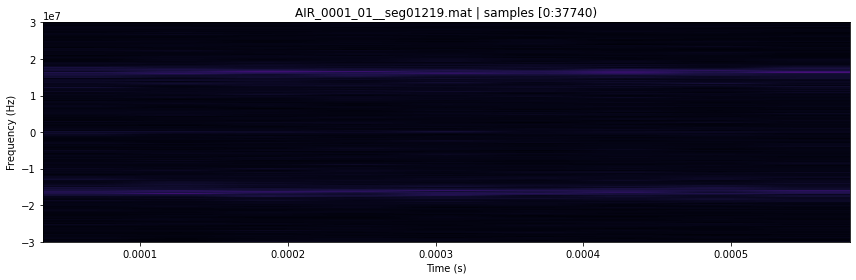

Displayed 37740 samples out of 37740 available.


In [63]:
plot_spectrogram(
    file_path=file_path,
    sample_rate=sample_rate,
    num_samples=num_samples,
    offset=offset,
    waveform_key=waveform_key,
)
